### Calculate Track Density
Track density: counts track points/time-steps/year

Code compiled from clee and skramer

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import sys
import os, glob
import xarray as xr


## most correct would probably be to seperate this... 
### get variables from chaz run
import Namelist as gv


In [4]:
# ============================================================
# Track-density for CHAZ–ERA models (ERA5)
#   + GLOBAL option
#   + plotting matches IBTrACS style:
#       - Atlantic-centered (central_longitude=0)
#       - extent [-180,180] and lat range (default -60 to 70)
#       - land gray, ocean white
#       - zeros transparent (so land stays gray but coastal density still shows)
#       - sequential colormap (default "Blues")
#       - user-controlled vmax for consistent colorbar across datasets
# ============================================================

# ======================
# Model configurations
# ======================

model_configs = {
    "ERA5-Original-CHAZ": {
        "base_dir": "/xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/",
        "ensemble_dirs": ["."],
        "sub_dir": ".",
        "file_pattern": "global_2019_2ens*_pre.nc",
        #"year_range": (1950, 2020),   
        "year_range": (gv.Year1, gv.Year2),  
        "output_dir": gv.output_path,
        "name": "ERA5-Original-CHAZ"
    },
     "ERA5-Updated-CHAZ": {
        "base_dir": gv.output_path,
        "ensemble_dirs": ["."],
        "sub_dir": ".",
        "file_pattern": "ERA5_*_ens0*.nc",
        "year_range": (gv.Year1, gv.Year2),
        "output_dir": gv.output_path,
        "name": "ERA5-Updated-CHAZ"
    }
}


In [23]:

def _to_0_360(lon):
    """Convert longitude array to [0, 360)."""
    return np.mod(lon, 360.0)

def _basin_bounds_0360(basin_key):
    """
    Basin bounds in 0–360E coordinates.

    ATL: ~100°W–20°E, 0–60°N  -> 260–380 (wrap)
    WNP: ~100°E–180°E, 0–50°N -> 100–180
    GLOBAL: handled via passed global lon/lat bounds (no fixed bounds here)
    """
    if basin_key == "ATL":
        return (260.0, 380.0, 0.0, 60.0)
    elif basin_key == "WNP":
        return (100.0, 180.0, 0.0, 50.0)
    elif basin_key == "GLOBAL":
        # placeholder; actual bounds handled by lon/lat global domain args
        return (0.0, 360.0, -90.0, 90.0)
    else:
        raise ValueError(f"Unknown basin_key={basin_key!r}")


def _enumerate_model_files(cfg):
    base_dir      = cfg["base_dir"]
    ensemble_dirs = cfg.get("ensemble_dirs", ["."])
    sub_dir       = cfg.get("sub_dir", ".")
    file_pattern  = cfg["file_pattern"]
    year_range    = cfg["year_range"]
    name          = cfg["name"]

    file_lists = []
    for ens in ensemble_dirs:
        ens_dir = os.path.join(base_dir, ens, sub_dir) if sub_dir != "." else os.path.join(base_dir, ens)
        file_lists.append(glob.glob(os.path.join(ens_dir, file_pattern)))

    files = sorted([f for sublist in file_lists for f in sublist])

    years_span = year_range[1] - year_range[0] + 1

    # if name == "ERA5-Updated-CHAZ":
    #     ## each file is an independent realization and year 
    #     nyears_eff = len(files)
    # else: 
    #     ### original data in clee folder
    #     nyears_eff = years_span * max(1, len(files))  # each file is an independent realization
    # return files, nyears_eff

    if name == 'ERA5-Updated-CHAZ':
        years = {str(y) for y in range(year_range[0], year_range[1] + 1)}
        fnames = sorted([
            f for f in files
            if f.split('_')[1] in years])

        nyears_eff = len(fnames)

    elif name == 'ERA5-Original-CHAZ':
        fnames = sorted(files)
        nyears_eff = years_span * max(1, len(fnames))

    else:
        raise ValueError(f"Unknown configuration: {name}")
    # if name == "ERA5-Updated-CHAZ":
    #         ## each file is an independent realization and year 
    #     nyears_eff = len(files)
    # else: 
    #     ### original data in clee folder
    #     nyears_eff = years_span * max(1, len(files))  # each file is an independent realization

    return fnames, nyears_eff


def collect_track_points_for_model(model_key, configs=None, min_wind_knots=34.0):
    if configs is None:
        configs = model_configs

    cfg = configs[model_key]
    files, nyears_eff = _enumerate_model_files(cfg)

    year_range = cfg["year_range"]

    lon_all = []
    lat_all = []

    for f in files:
        ds = xr.open_dataset(f)

        if "Mwspd" not in ds:
            ds.close()
            continue

        # Winds
        w_da = ds["Mwspd"]
        if "ensembleNum" in w_da.dims:
            w_da = w_da.isel(ensembleNum=0)
        wspd = w_da.values  # [time, storm]

        # Coordinates
        lon_da = ds["longitude"]
        lat_da = ds["latitude"]
        if "ensembleNum" in lon_da.dims:
            lon_da = lon_da.isel(ensembleNum=0)
            lat_da = lat_da.isel(ensembleNum=0)
        lon = lon_da.values  # [time, storm]
        lat = lat_da.values  # [time, storm]

        # Optional per-storm year
        if "year" in ds:
            years_storm = ds["year"].values  # [storm]
            years_2d = np.broadcast_to(years_storm[np.newaxis, :], wspd.shape)
        else:
            yr0, yr1 = year_range
            years_2d = np.full(wspd.shape, yr0, dtype=int)

        ds.close()

        # Clean / normalize
        lon = np.where(lon == -9999, np.nan, lon)
        lat = np.where(lat == -9999, np.nan, lat)
        wspd = np.where(wspd == -9999, np.nan, wspd)
        lon[lon < 0] += 360.0  # enforce 0–360E

        base_mask = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(wspd) & np.isfinite(years_2d)

        yr0, yr1 = year_range
        year_mask = (years_2d >= yr0) & (years_2d <= yr1)

        wind_mask = (wspd >= min_wind_knots)

        mask = base_mask & year_mask & wind_mask

        if np.any(mask):
            lon_all.append(lon[mask])
            lat_all.append(lat[mask])

    if not lon_all:
        raise RuntimeError(f"No qualifying track points found for {model_key} — check files & thresholds.")

    lon_all = np.concatenate(lon_all)
    lat_all = np.concatenate(lat_all)

    print(f"{model_key}: collected {lon_all.size} points ≥ {min_wind_knots} kt; effective years = {nyears_eff}")
    return lon_all, lat_all, nyears_eff


def compute_basin_track_density_for_model(lon_all, lat_all, nyears_eff,
                                          basin_key,
                                          dlon=2.0, dlat=2.0,
                                          lon_min_global=0.0, lon_max_global=360.0,
                                          lat_min_global=-60.0, lat_max_global=70.0):
    """
    Compute 2D track density (counts per year per grid cell) for one basin,
    including GLOBAL option.
    """
    lon_all = _to_0_360(lon_all)

    lon_edges = np.arange(lon_min_global, lon_max_global + dlon, dlon)
    lat_edges = np.arange(lat_min_global, lat_max_global + dlat, dlat)

    lon_min, lon_max, lat_min, lat_max = _basin_bounds_0360(basin_key)

    if basin_key == "ATL":
        basin_mask = ((lon_all >= lon_min) | (lon_all < lon_max - 360.0)) & \
                     (lat_all >= lat_min) & (lat_all <= lat_max)
    elif basin_key == "WNP":
        basin_mask = (lon_all >= lon_min) & (lon_all <= lon_max) & \
                     (lat_all >= lat_min) & (lat_all <= lat_max)
    elif basin_key == "GLOBAL":
        basin_mask = (lon_all >= lon_min_global) & (lon_all < lon_max_global) & \
                     (lat_all >= lat_min_global) & (lat_all <= lat_max_global)
    else:
        raise ValueError(f"Unknown basin_key={basin_key!r}")

    lon_b = lon_all[basin_mask]
    lat_b = lat_all[basin_mask]

    if lon_b.size == 0:
        density = np.zeros((lat_edges.size - 1, lon_edges.size - 1))
        return density, lon_edges, lat_edges

    H, xedges, yedges = np.histogram2d(
        lon_b, lat_b,
        bins=[lon_edges, lat_edges]
    )

    density = (H.T) / float(nyears_eff)  # [lat, lon]
    return density, lon_edges, lat_edges


def compute_and_save_track_density_for_model(model_key,
                                             basins=("GLOBAL", "ATL", "WNP"),
                                             min_wind_knots=34.0,
                                             dlon=2.0,
                                             dlat=2.0,
                                             lon_min_global=0.0,
                                             lon_max_global=360.0,
                                             lat_min_global=-60.0,
                                             lat_max_global=70.0,
                                             configs=None):
    """
    Compute track density for requested basins (now includes GLOBAL) and save NPZ.
    """
    if configs is None:
        configs = model_configs

    if isinstance(basins, str):
        basins = (basins,)
    else:
        basins = tuple(basins)

    print(f"\n=== Track density for model: {model_key} (≥{min_wind_knots} kt) ===")
    lon_all, lat_all, nyears_eff = collect_track_points_for_model(
        model_key,
        configs=configs,
        min_wind_knots=min_wind_knots,
    )

    cfg = configs[model_key]
    out_root = cfg["output_dir"]
    out_dir = os.path.join(out_root, "TrackDensity")
    os.makedirs(out_dir, exist_ok=True)

    results = {}

    for basin_key in basins:
        print(f"  Computing basin density: {basin_key}")
        dens, lon_edges, lat_edges = compute_basin_track_density_for_model(
            lon_all, lat_all, nyears_eff,
            basin_key=basin_key,
            dlon=dlon,
            dlat=dlat,
            lon_min_global=lon_min_global,
            lon_max_global=lon_max_global,
            lat_min_global=lat_min_global,
            lat_max_global=lat_max_global,
        )
        results[basin_key] = (dens, lon_edges, lat_edges)

        outpath = os.path.join(out_dir, f"track_density_{model_key}_{basin_key}.npz")
        np.savez(
            outpath,
            density=dens,
            lon_edges=lon_edges,
            lat_edges=lat_edges,
            nyears_eff=nyears_eff,
            min_wind_knots=min_wind_knots,
            dlon=dlon,
            dlat=dlat,
            basin_key=basin_key,
            lon_min_global=lon_min_global,
            lon_max_global=lon_max_global,
            lat_min_global=lat_min_global,
            lat_max_global=lat_max_global,
        )
        print(f"    Saved NPZ: {outpath}")

    return results


# ============================================================
# Plotting helper (matches IBTrACS style)
#   - Atlantic-centered
#   - extent +/-180 and lat range [-60, 70] (or whatever you pass)
#   - land gray, ocean white
#   - zeros transparent so land stays gray but coastal density still shows
#   - fixed vmax optional for comparable colorbars
# ============================================================
def plot_track_density_0360(density, lon_edges, lat_edges, title, 
                            basin_key = 'Global', extent = 'auto',
                            cmap="Blues", vmax=None, vmin = 0,
                            central_longitude=0,
                            extent_lon=(-180, 180),
                            extent_lat=(-60, 70)):
    lon2d, lat2d = np.meshgrid(lon_edges, lat_edges)

    # extent selection (in -180..180 display coords)
    basin_up = (basin_key or "").upper()
    if extent == "auto":
        if basin_up == "ATL":
            ext = (-100, 20, 0, 60)
        elif basin_up == "WNP":
            ext = (100, 180, 0, 50)
        else:
            ext = (-180, 180, extent_lat[0], extent_lat[1])
    elif extent == "global":
        ext = (-180, 180, extent_lat[0], extent_lat[1])
    else:
        ext = extent

    fig = plt.figure(figsize=(14, 6))
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=central_longitude))

    # Domain
    #ax.set_extent([extent_lon[0], extent_lon[1], extent_lat[0], extent_lat[1]],
    #              crs=ccrs.PlateCarree())
    ax.set_extent(ext, crs = ccrs.PlateCarree())

    # Base layers
    ax.set_facecolor("white")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none", zorder=0)

    # Mask zeros -> transparent
    dens_plot = np.array(density, dtype=float)
    dens_plot[dens_plot <= 0] = np.nan

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad((1, 1, 1, 0))  # NaN transparent


    pm = ax.pcolormesh(
        lon2d, lat2d, dens_plot,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        vmin=vmin,
        vmax=vmax,
        zorder=1
    )

    ax.coastlines(linewidth=0.6, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5, zorder=3)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle="--", alpha=0.5, zorder=4)
    gl.top_labels = False
    gl.right_labels = False

    cb = plt.colorbar(pm, ax=ax, orientation="vertical", shrink=0.8, pad=0.02)
    cb.set_label("Track density (counts per year per 2°×2° cell)")

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return fig, ax


In [24]:
# ============================================================
# Example run + plots (GLOBAL, ATL, WNP) for ERA5
# ============================================================
# Choose one vmax to reuse across datasets for apples-to-apples comparisons
# (set based on IBTrACS peak, e.g., 6)
#VMMAX = 6
VMMAX = 4

# era5_results = compute_and_save_track_density_for_model(
#     "ERA5-Original-CHAZ",
#     basins=("GLOBAL",),
#     min_wind_knots=34.0,
#     dlon=2.0,
#     dlat=2.0,
#     lat_min_global=-60.0,
#     lat_max_global=70.0,
# )

# for basin_key in ("GLOBAL",):
#     dens, lon_edges, lat_edges = era5_results[basin_key]
#     plot_track_density_0360(
#         dens, lon_edges, lat_edges,
#         title=f"Original CHAZ-ERA5 Track Density ({basin_key}) | {gv.Year1}-{gv.Year2} | ≥34 kt",
#         cmap="Blues",
#         vmax=VMMAX
#     )

original_era5_results = compute_and_save_track_density_for_model(
    "ERA5-Original-CHAZ",
    basins=("GLOBAL", "ATL", "WNP"),
    min_wind_knots=34.0,
    dlon=2.0,
    dlat=2.0,
    lat_min_global=-60.0,
    lat_max_global=70.0,
)

updated_era5_results = compute_and_save_track_density_for_model(
    "ERA5-Updated-CHAZ",
    basins=("GLOBAL",'ATL', 'WNP'),
    min_wind_knots=34.0,
    dlon=2.0,
    dlat=2.0,
    lat_min_global=-60.0,
    lat_max_global=70.0,
)


=== Track density for model: ERA5-Original-CHAZ (≥34.0 kt) ===
ERA5-Original-CHAZ: collected 1103386 points ≥ 34.0 kt; effective years = 600
  Computing basin density: GLOBAL
    Saved NPZ: output/TrackDensity/track_density_ERA5-Original-CHAZ_GLOBAL.npz
  Computing basin density: ATL
    Saved NPZ: output/TrackDensity/track_density_ERA5-Original-CHAZ_ATL.npz
  Computing basin density: WNP
    Saved NPZ: output/TrackDensity/track_density_ERA5-Original-CHAZ_WNP.npz

=== Track density for model: ERA5-Updated-CHAZ (≥34.0 kt) ===
ERA5-Updated-CHAZ: collected 167542 points ≥ 34.0 kt; effective years = 99
  Computing basin density: GLOBAL
    Saved NPZ: output/TrackDensity/track_density_ERA5-Updated-CHAZ_GLOBAL.npz
  Computing basin density: ATL
    Saved NPZ: output/TrackDensity/track_density_ERA5-Updated-CHAZ_ATL.npz
  Computing basin density: WNP
    Saved NPZ: output/TrackDensity/track_density_ERA5-Updated-CHAZ_WNP.npz


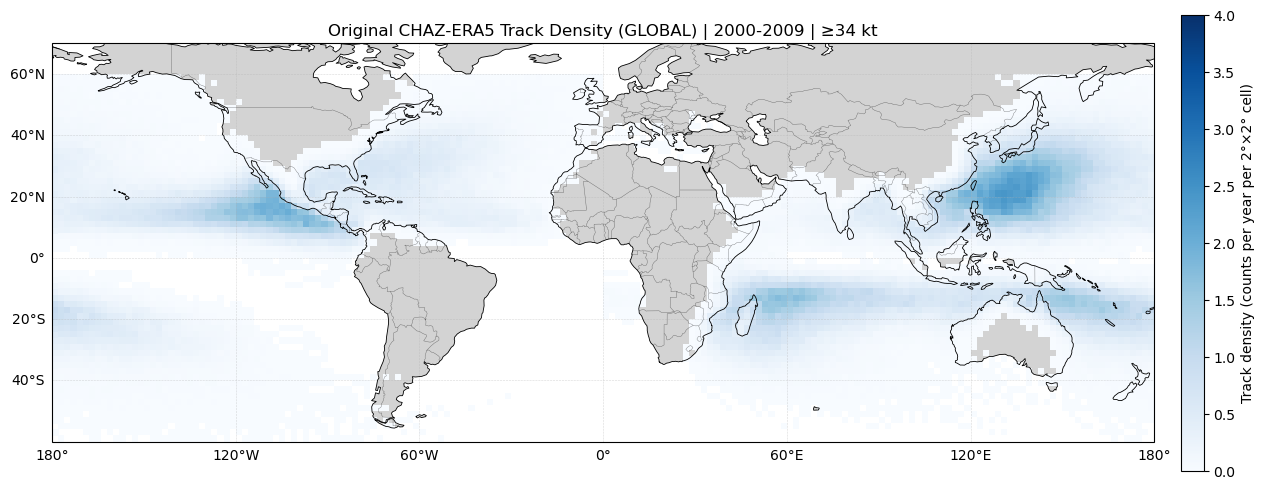

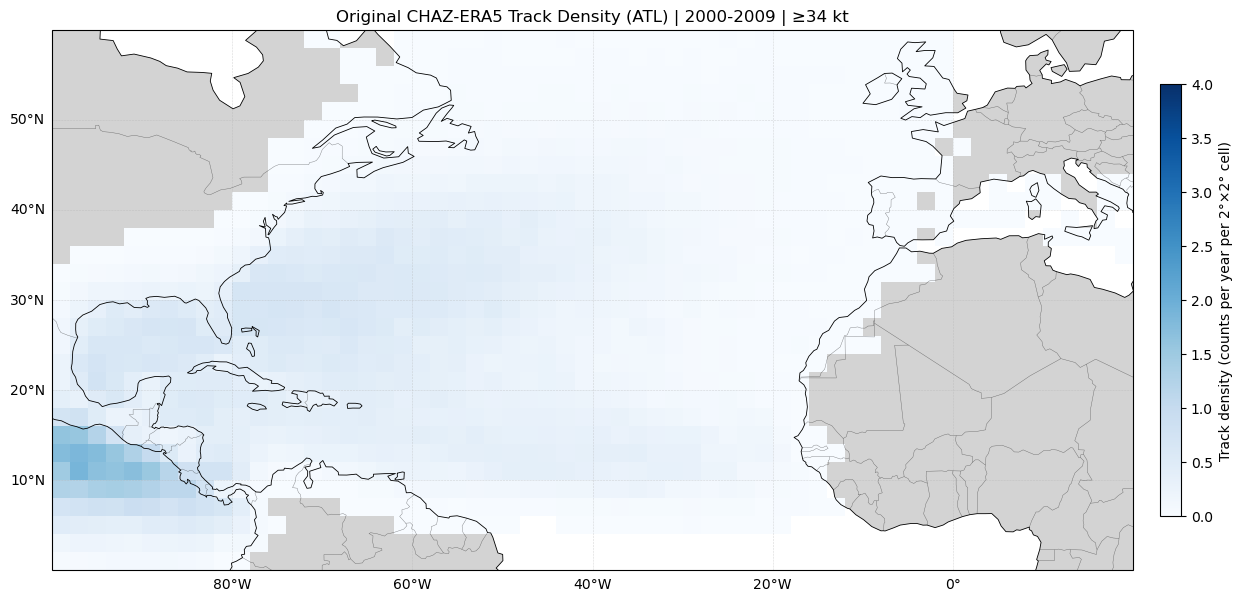

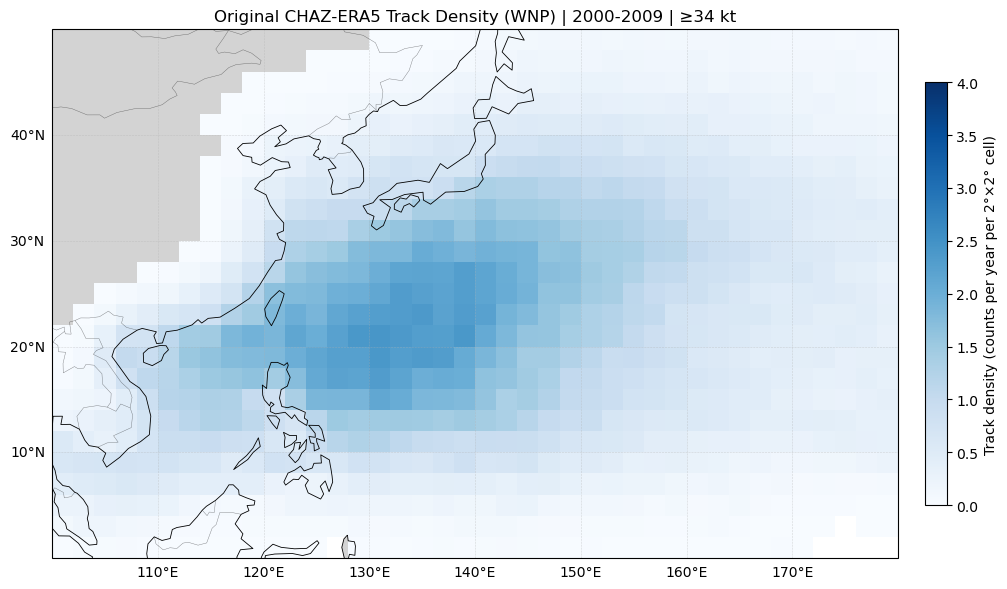

In [25]:
for basin_key in ("GLOBAL","ATL", "WNP"):
    dens, lon_edges, lat_edges = original_era5_results[basin_key]
    plot_track_density_0360(
        dens, lon_edges, lat_edges,
        title=f"Original CHAZ-ERA5 Track Density ({basin_key}) | {gv.Year1}-{gv.Year2} | ≥34 kt",
        basin_key = basin_key,
        cmap="Blues",
        vmax=VMMAX
    )


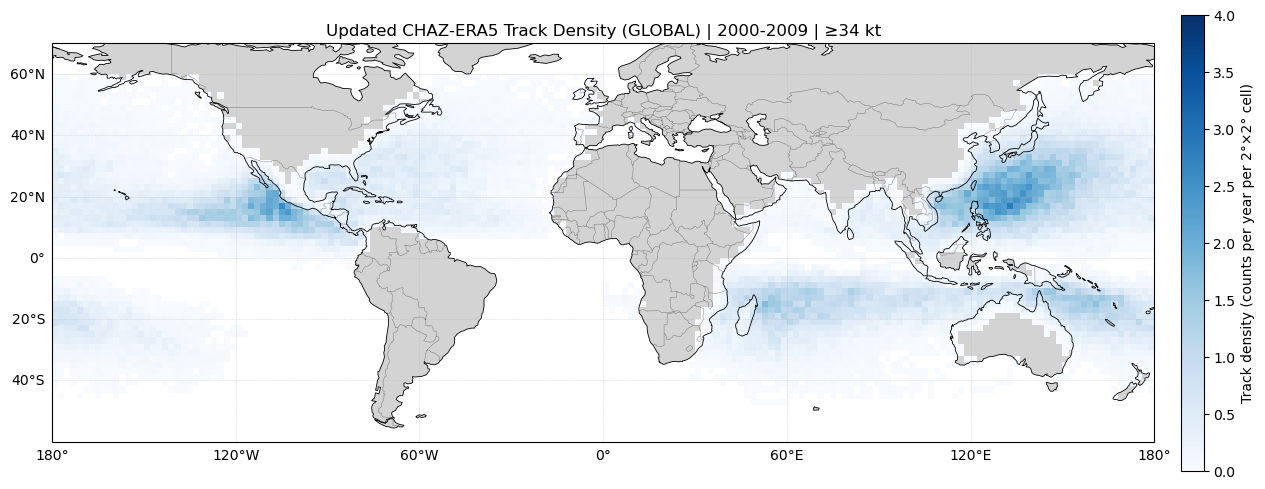

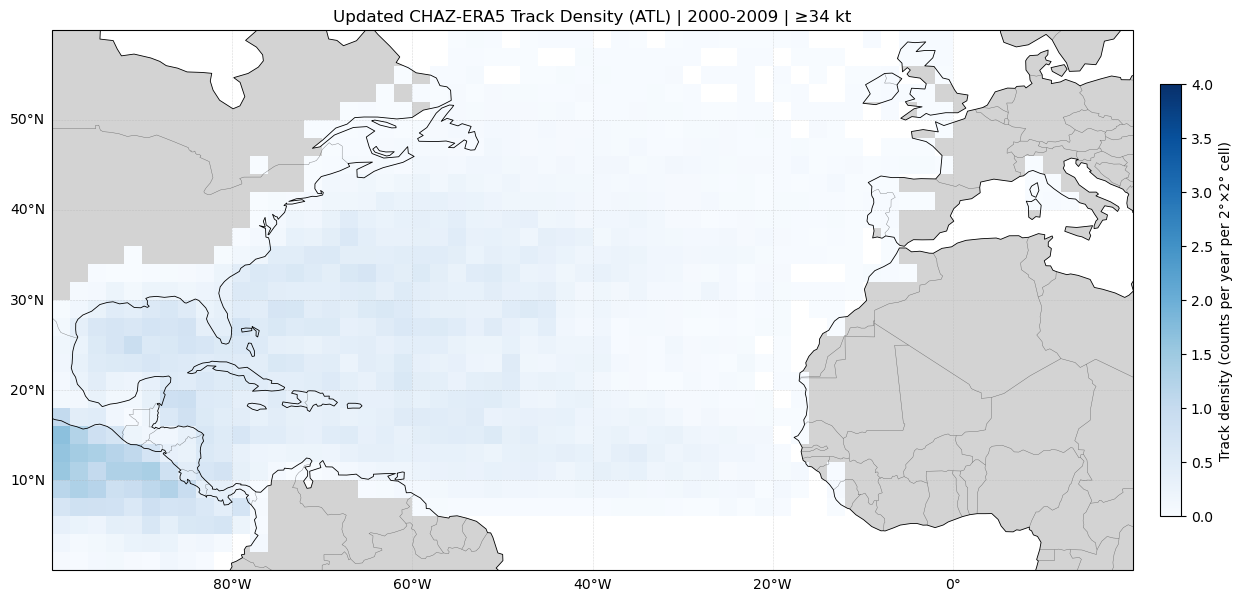

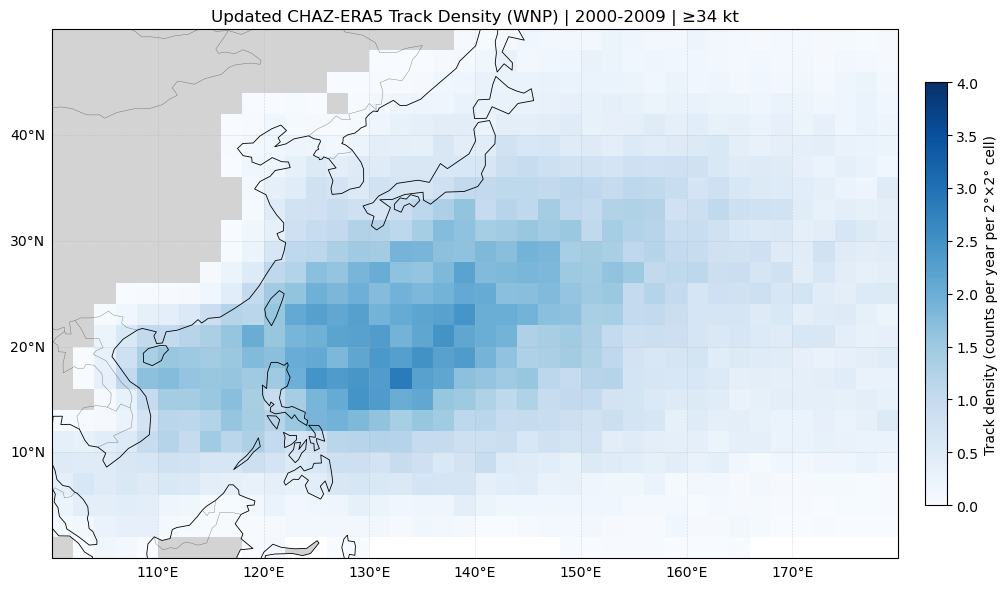

In [26]:

for basin_key in ("GLOBAL", 'ATL', "WNP"):
    dens, lon_edges, lat_edges = updated_era5_results[basin_key]
    plot_track_density_0360(
        dens, lon_edges, lat_edges,
        title=f"Updated CHAZ-ERA5 Track Density ({basin_key}) | {gv.Year1}-{gv.Year2} | ≥34 kt",
        cmap="Blues",
        basin_key = basin_key,
        vmax=VMMAX
    )

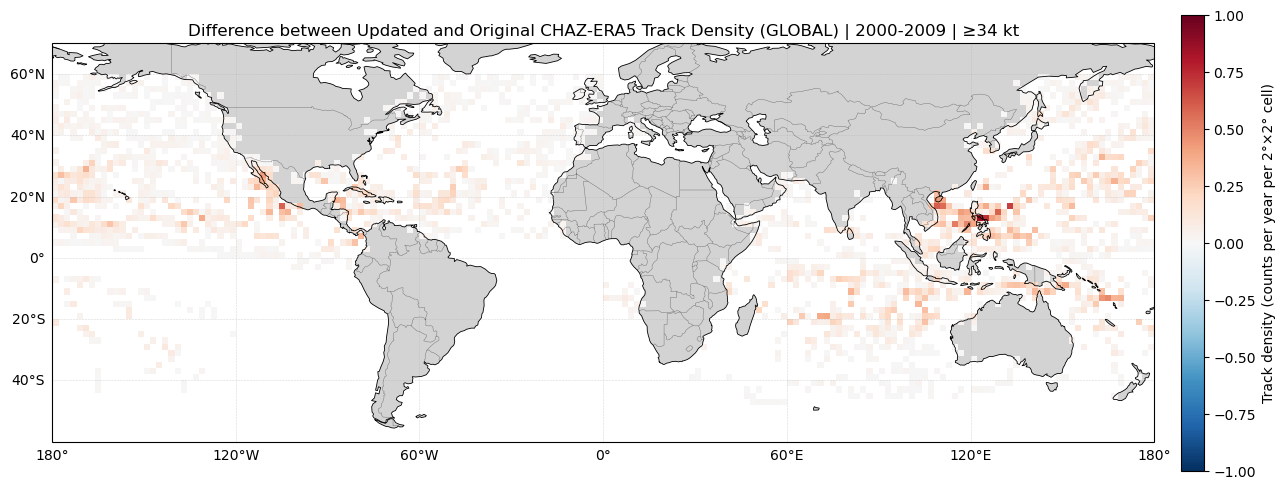

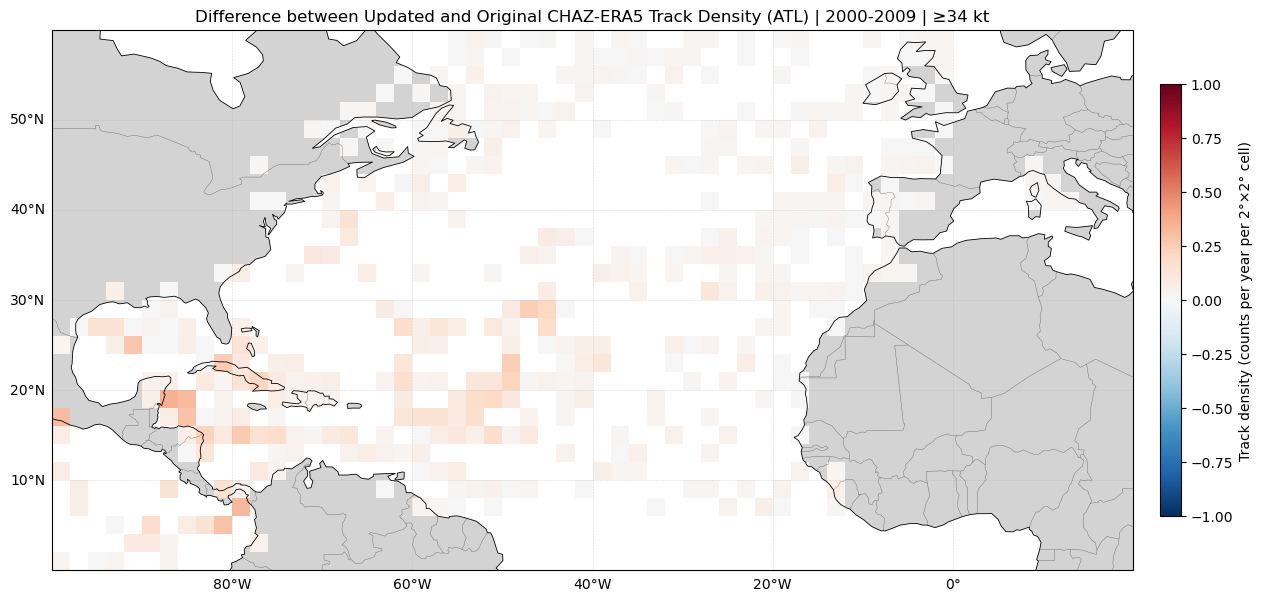

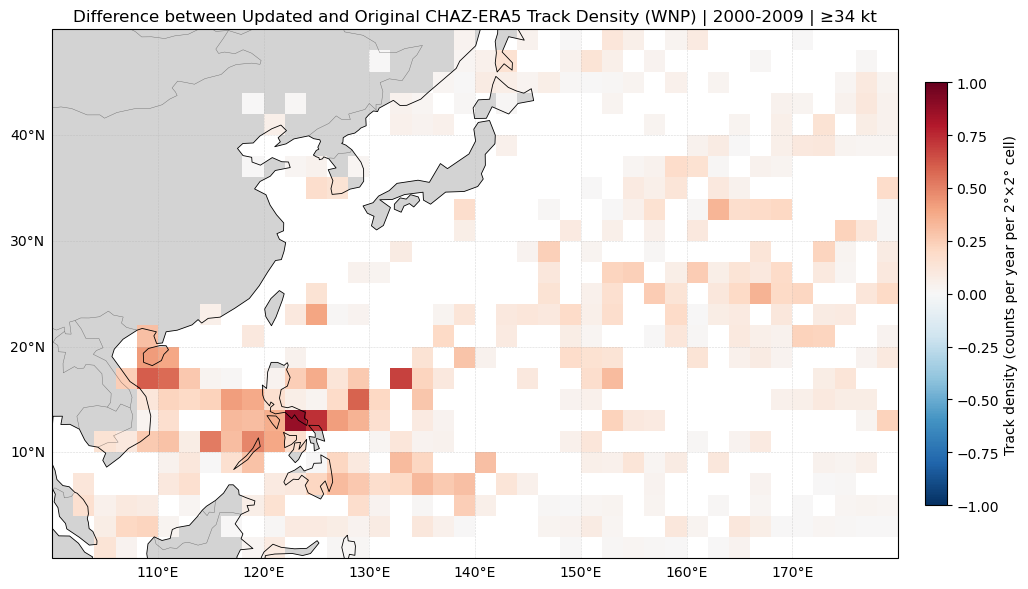

In [29]:
#basin_key = 'GLOBAL'
for basin_key in ['GLOBAL', 'ATL', "WNP"]:
    dens_u, lon_edges_u, lat_edges_u = updated_era5_results[basin_key]
    dens_o, lon_edges_o, lat_edges_o = original_era5_results[basin_key]

    dens = dens_u - dens_o

    plot_track_density_0360(
        dens, lon_edges_u, lat_edges_u,
        title=f"Difference between Updated and Original CHAZ-ERA5 Track Density ({basin_key}) | {gv.Year1}-{gv.Year2} | ≥34 kt",
        cmap="RdBu_r",         basin_key = basin_key,
        vmax = 1,
        vmin = -1
        )